# Diffraction Estimation with Jitter and Vacancy

In this notebook, we extend the earlier diffraction-based disorder estimation problem by introducing two different mechanisms of structural disorder:

- **positional jitter**: surviving lattice points are randomly displaced from their ideal locations
- **vacancy**: some lattice points are removed entirely

The goal is to test whether a diffraction pattern contains enough information to estimate both disorder parameters simultaneously.

For each generated lattice, the model will try to predict:

- the jitter level \( \sigma \)
- the vacancy fraction

This is a more difficult problem than the earlier single-parameter jitter-only case, because the diffraction pattern now reflects two coupled mechanisms of order breakdown.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
def create_lattice_with_jitter_vacancy(
    n_points=10,
    grid_size=128,
    jitter_sigma=0.0,
    vacancy_fraction=0.0
):
    img = np.zeros((grid_size, grid_size))

    spacing = grid_size / (n_points + 2)
    coords = np.arange(n_points) * spacing
    lattice_span = coords[-1] - coords[0]
    start = (grid_size - lattice_span) / 2.0

    for i in range(n_points):
        for j in range(n_points):
            # apply vacancy first
            if np.random.rand() < vacancy_fraction:
                continue

            x = start + i * spacing
            y = start + j * spacing

            # apply positional jitter to surviving points
            x += np.random.normal(0, jitter_sigma * spacing)
            y += np.random.normal(0, jitter_sigma * spacing)

            xi = int(np.clip(round(x), 0, grid_size - 1))
            yi = int(np.clip(round(y), 0, grid_size - 1))

            img[yi, xi] = 1.0

    return img

In [3]:
def compute_diffraction(img, normalize=True):
    F = np.fft.fftshift(np.fft.fft2(img))
    I = np.abs(F) ** 2
    I_log = np.log1p(I)

    if normalize:
        I_log = (I_log - I_log.min()) / (I_log.max() - I_log.min() + 1e-8)

    return I_log

In [19]:
sigma_levels = [0.00, 0.03, 0.06, 0.09, 0.12, 0.15]
vacancy_levels = [0.00, 0.10, 0.20, 0.30, 0.40]

samples_per_combo = 100

n_points = 10
grid_size = 128

n_realizations = 4

In [20]:
X = []
y = []

for sigma in sigma_levels:
    for vacancy in vacancy_levels:
        for _ in range(samples_per_combo):
            img = create_lattice_with_jitter_vacancy(
                n_points=n_points,
                grid_size=grid_size,
                jitter_sigma=sigma,
                vacancy_fraction=vacancy
            )
            diff = compute_diffraction(img, normalize=True)

            X.append(diff)
            y.append([sigma, vacancy])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3000, 128, 128)
y shape: (3000, 2)


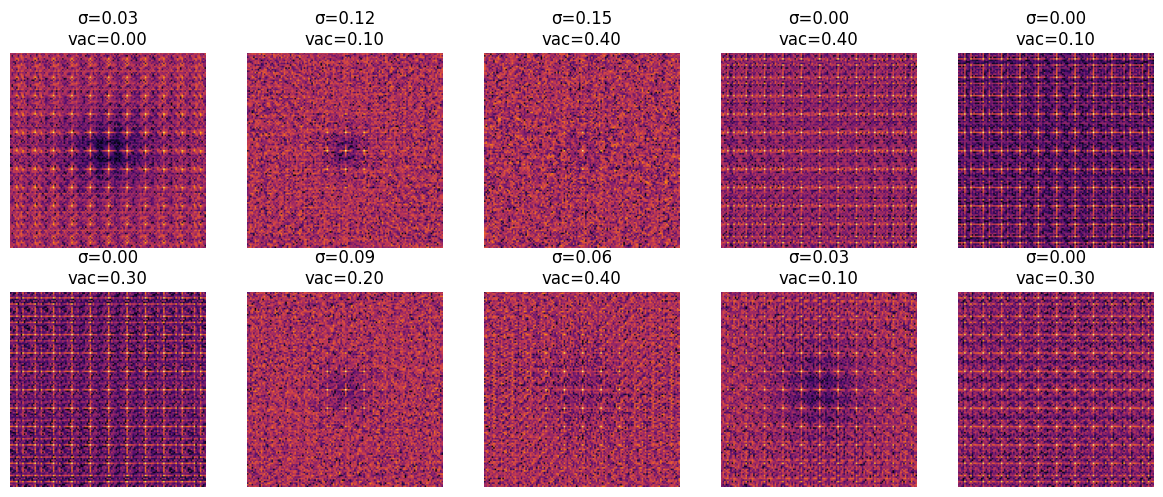

In [21]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

sample_indices = np.random.choice(len(X), size=10, replace=False)

for ax, idx in zip(axes.flat, sample_indices):
    ax.imshow(X[idx], cmap='inferno')
    ax.set_title(f"σ={y[idx,0]:.2f}\nvac={y[idx,1]:.2f}")
    ax.axis('off')

plt.tight_layout()
plt.show()

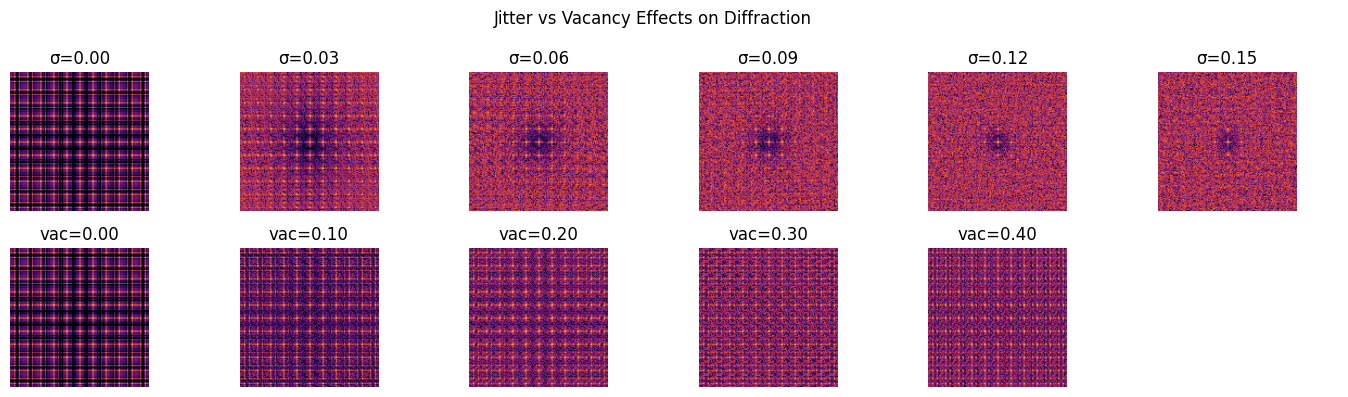

In [22]:
sigma_levels = [0.00, 0.03, 0.06, 0.09, 0.12, 0.15]
vacancy_levels = [0.00, 0.10, 0.20, 0.30, 0.40]

n_cols = max(len(sigma_levels), len(vacancy_levels))

fig, axes = plt.subplots(2, n_cols, figsize=(14, 4))

# Row 1: Jitter only
for col in range(n_cols):
    if col < len(sigma_levels):
        sigma = sigma_levels[col]

        img = create_lattice_with_jitter_vacancy(
            n_points=n_points,
            grid_size=grid_size,
            jitter_sigma=sigma,
            vacancy_fraction=0.0
        )
        diff = compute_diffraction(img, normalize=True)

        axes[0, col].imshow(diff, cmap='inferno')
        axes[0, col].set_title(f"σ={sigma:.2f}")
    else:
        axes[0, col].axis('off')

    axes[0, col].axis('off')


# Row 2: Vacancy only
for col in range(n_cols):
    if col < len(vacancy_levels):
        vacancy = vacancy_levels[col]

        img = create_lattice_with_jitter_vacancy(
            n_points=n_points,
            grid_size=grid_size,
            jitter_sigma=0.0,
            vacancy_fraction=vacancy
        )
        diff = compute_diffraction(img, normalize=True)

        axes[1, col].imshow(diff, cmap='inferno')
        axes[1, col].set_title(f"vac={vacancy:.2f}")
    else:
        axes[1, col].axis('off')

    axes[1, col].axis('off')


axes[0, 0].set_ylabel("Jitter", fontsize=12)
axes[1, 0].set_ylabel("Vacancy", fontsize=12)

plt.suptitle("Jitter vs Vacancy Effects on Diffraction")
plt.tight_layout()
plt.show()

In [23]:
X_flat = X.reshape(len(X), -1)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y, test_size=0.2, random_state=42
)

In [25]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [26]:
y_pred = rf.predict(X_test)

sigma_true = y_test[:, 0]
vac_true = y_test[:, 1]

sigma_pred = y_pred[:, 0]
vac_pred = y_pred[:, 1]

In [27]:
print("Sigma Prediction:")
print("MAE :", mean_absolute_error(sigma_true, sigma_pred))
print("RMSE:", np.sqrt(mean_squared_error(sigma_true, sigma_pred)))
print("R2  :", r2_score(sigma_true, sigma_pred))

print("\nVacancy Prediction:")
print("MAE :", mean_absolute_error(vac_true, vac_pred))
print("RMSE:", np.sqrt(mean_squared_error(vac_true, vac_pred)))
print("R2  :", r2_score(vac_true, vac_pred))

Sigma Prediction:
MAE : 0.009818500000000018
RMSE: 0.013050732738049646
R2  : 0.9369360767408641

Vacancy Prediction:
MAE : 0.0560958333333334
RMSE: 0.07220306722478402
R2  : 0.7332661778583767


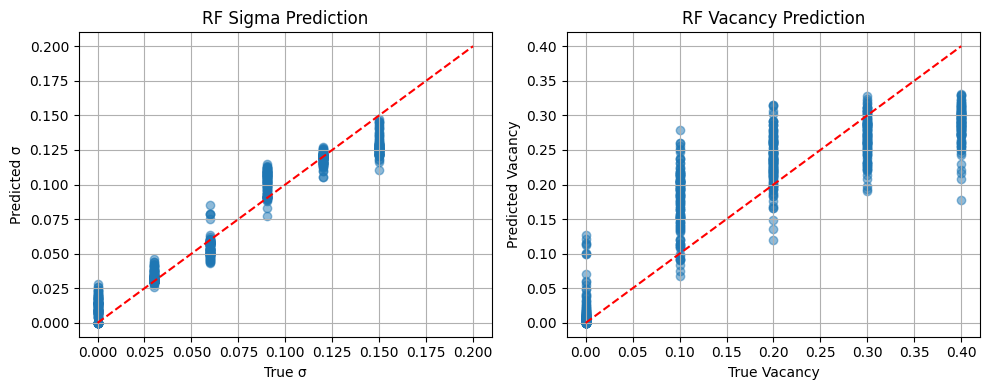

In [54]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(sigma_true, sigma_pred, alpha=0.5)
plt.plot([0, 0.2], [0, 0.2], 'r--')
plt.xlabel("True σ")
plt.ylabel("Predicted σ")
plt.title("RF Sigma Prediction")
plt.grid(True)

plt.subplot(1,2,2)
plt.scatter(vac_true, vac_pred, alpha=0.5)
plt.plot([0, 0.4], [0, 0.4], 'r--')
plt.xlabel("True Vacancy")
plt.ylabel("Predicted Vacancy")
plt.title("RF Vacancy Prediction")
plt.grid(True)

plt.tight_layout()
plt.show()

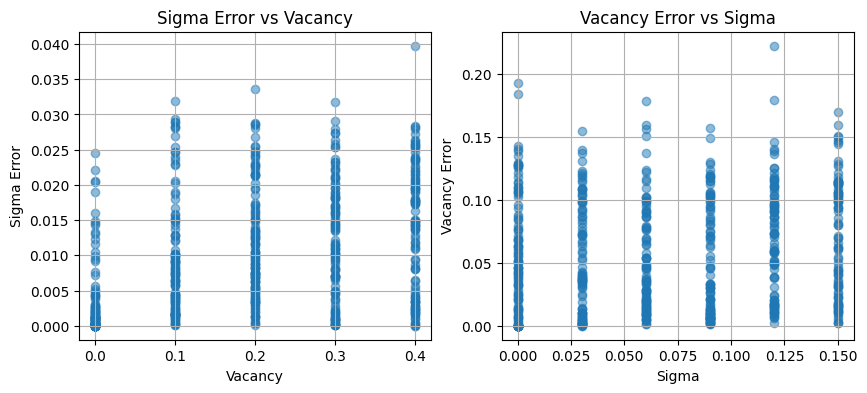

In [50]:
sigma_error = np.abs(sigma_true - sigma_pred)
vac_error = np.abs(vac_true - vac_pred)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(vac_true, sigma_error, alpha=0.5)
plt.xlabel("Vacancy")
plt.ylabel("Sigma Error")
plt.title("Sigma Error vs Vacancy")
plt.grid(True)

plt.subplot(1,2,2)
plt.scatter(sigma_true, vac_error, alpha=0.5)
plt.xlabel("Sigma")
plt.ylabel("Vacancy Error")
plt.title("Vacancy Error vs Sigma")
plt.grid(True)
plt.show()

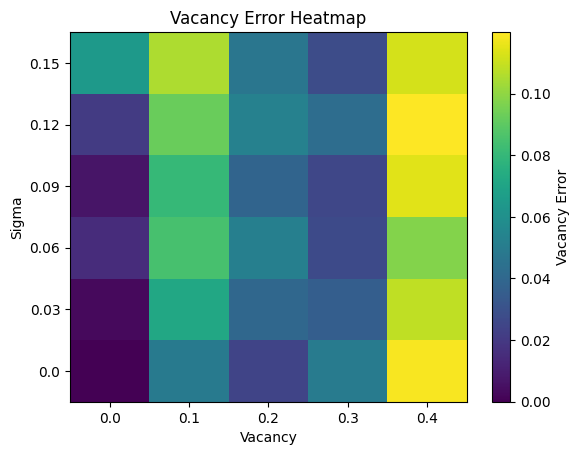

In [32]:
import pandas as pd

df = pd.DataFrame({
    "sigma": sigma_true,
    "vac": vac_true,
    "sigma_err": np.abs(sigma_true - sigma_pred),
    "vac_err": np.abs(vac_true - vac_pred)
})

pivot = df.pivot_table(
    values="vac_err",
    index="sigma",
    columns="vac",
    aggfunc="mean"
)

plt.imshow(pivot, origin='lower', aspect='auto')
plt.colorbar(label="Vacancy Error")
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xlabel("Vacancy")
plt.ylabel("Sigma")
plt.title("Vacancy Error Heatmap")
plt.show()

## CNN Regression Baseline

We now train a compact convolutional neural network (CNN) to predict both disorder parameters directly from the diffraction image.

Unlike the random forest baseline, the CNN operates on the 2D image structure directly. This allows us to test whether spatial feature learning improves joint estimation of jitter and vacancy.

In [33]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [34]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


In [35]:
X_train_img, X_test_img, y_train_img, y_test_img = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train_img.shape, X_test_img.shape)
print(y_train_img.shape, y_test_img.shape)

(2400, 128, 128) (600, 128, 128)
(2400, 2) (600, 2)


In [36]:
max_sigma = max(sigma_levels)
max_vacancy = max(vacancy_levels)

y_train_norm = y_train_img.copy().astype(np.float32)
y_test_norm = y_test_img.copy().astype(np.float32)

y_train_norm[:, 0] /= max_sigma
y_train_norm[:, 1] /= max_vacancy

y_test_norm[:, 0] /= max_sigma
y_test_norm[:, 1] /= max_vacancy

In [37]:
X_train_tensor = torch.tensor(X_train_img[:, None, :, :], dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_img[:, None, :, :], dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_norm, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_norm, dtype=torch.float32)

train_ds = TensorDataset(X_train_tensor, y_train_tensor)
test_ds = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

In [38]:
class DiffractionCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.regressor(x)
        return x

In [39]:
model = DiffractionCNN().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [40]:
n_epochs = 12

train_losses = []

for epoch in range(n_epochs):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    print(f"Epoch {epoch+1}/{n_epochs} - Train Loss: {epoch_loss:.6f}")

Epoch 1/12 - Train Loss: 0.155128
Epoch 2/12 - Train Loss: 0.056991
Epoch 3/12 - Train Loss: 0.023219
Epoch 4/12 - Train Loss: 0.016962
Epoch 5/12 - Train Loss: 0.016323
Epoch 6/12 - Train Loss: 0.016637
Epoch 7/12 - Train Loss: 0.012804
Epoch 8/12 - Train Loss: 0.015085
Epoch 9/12 - Train Loss: 0.012492
Epoch 10/12 - Train Loss: 0.011617
Epoch 11/12 - Train Loss: 0.011274
Epoch 12/12 - Train Loss: 0.009538


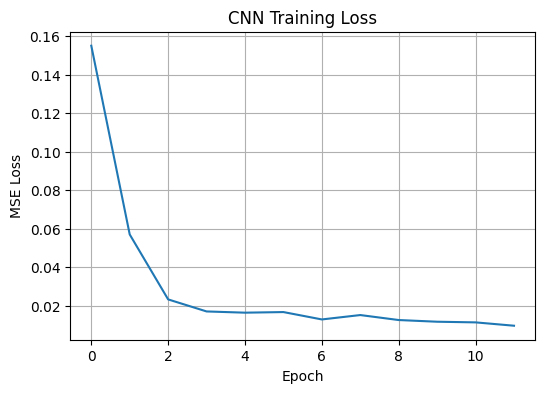

In [41]:
plt.figure(figsize=(6,4))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("CNN Training Loss")
plt.grid(True)
plt.show()

In [42]:
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        preds = model(xb).cpu().numpy()

        all_preds.append(preds)
        all_targets.append(yb.numpy())

y_pred_cnn_norm = np.vstack(all_preds)
y_true_cnn_norm = np.vstack(all_targets)

In [43]:
y_pred_cnn = y_pred_cnn_norm.copy()
y_true_cnn = y_true_cnn_norm.copy()

y_pred_cnn[:, 0] *= max_sigma
y_pred_cnn[:, 1] *= max_vacancy

y_true_cnn[:, 0] *= max_sigma
y_true_cnn[:, 1] *= max_vacancy

sigma_true_cnn = y_true_cnn[:, 0]
vac_true_cnn = y_true_cnn[:, 1]

sigma_pred_cnn = y_pred_cnn[:, 0]
vac_pred_cnn = y_pred_cnn[:, 1]

In [44]:
print("CNN Sigma Prediction:")
print("MAE :", mean_absolute_error(sigma_true_cnn, sigma_pred_cnn))
print("RMSE:", np.sqrt(mean_squared_error(sigma_true_cnn, sigma_pred_cnn)))
print("R2  :", r2_score(sigma_true_cnn, sigma_pred_cnn))

print("\nCNN Vacancy Prediction:")
print("MAE :", mean_absolute_error(vac_true_cnn, vac_pred_cnn))
print("RMSE:", np.sqrt(mean_squared_error(vac_true_cnn, vac_pred_cnn)))
print("R2  :", r2_score(vac_true_cnn, vac_pred_cnn))

CNN Sigma Prediction:
MAE : 0.007442069705575705
RMSE: 0.011109612733893375
R2  : 0.9543007612228394

CNN Vacancy Prediction:
MAE : 0.03984839841723442
RMSE: 0.050586059378694384
R2  : 0.869073212146759


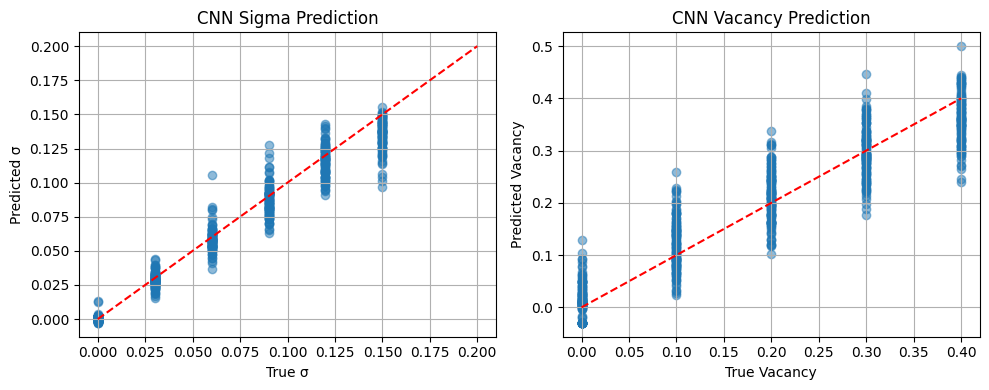

In [45]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(sigma_true_cnn, sigma_pred_cnn, alpha=0.5)
plt.plot([0, 0.2], [0, 0.2], 'r--')
plt.xlabel("True σ")
plt.ylabel("Predicted σ")
plt.title("CNN Sigma Prediction")
plt.grid(True)

plt.subplot(1,2,2)
plt.scatter(vac_true_cnn, vac_pred_cnn, alpha=0.5)
plt.plot([0, 0.4], [0, 0.4], 'r--')
plt.xlabel("True Vacancy")
plt.ylabel("Predicted Vacancy")
plt.title("CNN Vacancy Prediction")
plt.grid(True)

plt.tight_layout()
plt.show()

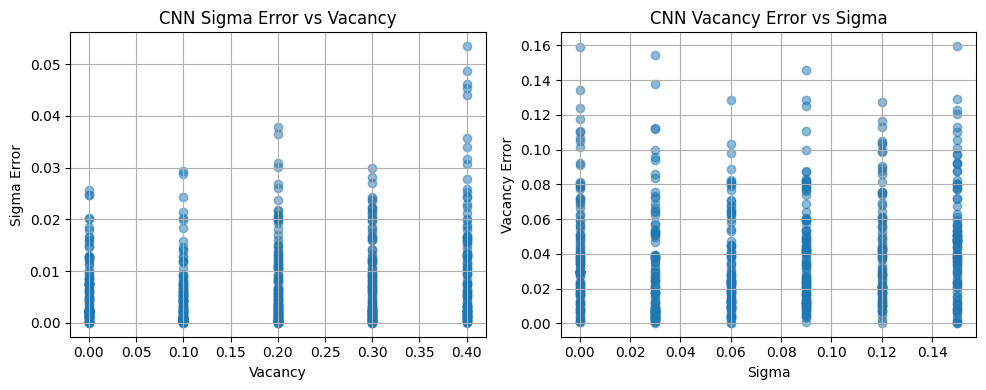

In [46]:
sigma_error_cnn = np.abs(sigma_true_cnn - sigma_pred_cnn)
vac_error_cnn = np.abs(vac_true_cnn - vac_pred_cnn)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(vac_true_cnn, sigma_error_cnn, alpha=0.5)
plt.xlabel("Vacancy")
plt.ylabel("Sigma Error")
plt.title("CNN Sigma Error vs Vacancy")
plt.grid(True)

plt.subplot(1,2,2)
plt.scatter(sigma_true_cnn, vac_error_cnn, alpha=0.5)
plt.xlabel("Sigma")
plt.ylabel("Vacancy Error")
plt.title("CNN Vacancy Error vs Sigma")
plt.grid(True)

plt.tight_layout()
plt.show()

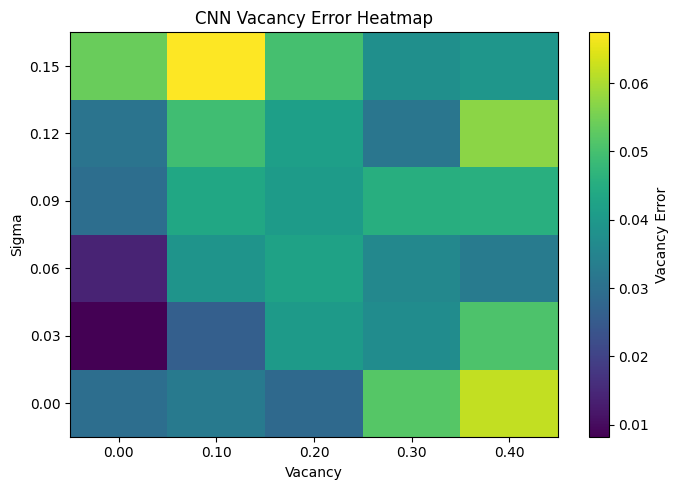

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_cnn = pd.DataFrame({
    "sigma": sigma_true_cnn,
    "vac": vac_true_cnn,
    "vac_err": vac_error_cnn
})

pivot_cnn = df_cnn.pivot_table(
    values="vac_err",
    index="sigma",
    columns="vac",
    aggfunc="mean"
)

# force-clean the displayed axis values
pivot_cnn.index = np.round(pivot_cnn.index.values.astype(float), 2)
pivot_cnn.columns = np.round(pivot_cnn.columns.values.astype(float), 2)

plt.figure(figsize=(7, 5))
plt.imshow(pivot_cnn, origin='lower', aspect='auto')
plt.colorbar(label="Vacancy Error")

plt.xticks(
    range(len(pivot_cnn.columns)),
    [f"{v:.2f}" for v in pivot_cnn.columns]
)
plt.yticks(
    range(len(pivot_cnn.index)),
    [f"{v:.2f}" for v in pivot_cnn.index]
)

plt.xlabel("Vacancy")
plt.ylabel("Sigma")
plt.title("CNN Vacancy Error Heatmap")
plt.tight_layout()
plt.show()